# Denoising Diffusion Probabilistic Model (DDPM) on Fashion-MNIST

This notebook implements a lightweight DDPM to generate 28x28 grayscale images from the Fashion-MNIST dataset. 

### Architecture Overview
* **Noise Schedule:** Linear schedule from $\beta_1 = 10^{-4}$ to $\beta_T = 0.02$.
* **Model:** A compact 2D U-Net with Sinusoidal Positional Embeddings to inject the timestep $t$ into the residual blocks.
* **Objective:** Predict the noise $\epsilon$ added at timestep $t$ using Mean Squared Error (MSE).

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1. Data Loading
We scale the images to the $[-1, 1]$ range, which is standard practice for diffusion models to stabilize the gradient flow during training.

In [2]:
BATCH_SIZE = 128
EPOCHS = 10
T = 500  # Total diffusion timesteps (kept lower for faster local testing)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Scale to [-1, 1]
])

dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

### 2. The Forward Process (Noise Scheduler)
We pre-calculate $\beta_t$, $\alpha_t$, and $\bar{\alpha}_t$ so we can sample $x_t$ at any arbitrary timestep without iterating through the entire Markov chain.

In [3]:
class LinearNoiseScheduler:
    def __init__(self, num_timesteps, beta_start=1e-4, beta_end=0.02):
        self.num_timesteps = num_timesteps
        self.beta = torch.linspace(beta_start, beta_end, num_timesteps).to(device)
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)
        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - self.alpha_bar)
        
    def add_noise(self, x_start, t, noise):
        sqrt_alpha_bar_t = self.sqrt_alpha_bar[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)
        return sqrt_alpha_bar_t * x_start + sqrt_one_minus_alpha_bar_t * noise

scheduler = LinearNoiseScheduler(num_timesteps=T)

### 3. The U-Net Architecture
A custom, lightweight U-Net. It uses Sinusoidal Positional Embeddings to encode the timestep $t$, projecting it into the feature dimension of the convolutional blocks so the network knows the noise level.

In [4]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

    def forward(self, x, t_emb):
        h = F.relu(self.conv1(x))
        time_emb = F.relu(self.time_mlp(t_emb))[(..., ) + (None, ) * 2]
        h = h + time_emb
        return F.relu(self.conv2(h))

class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        time_emb_dim = 32
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        
        # Down
        self.down1 = Block(1, 64, time_emb_dim)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = Block(64, 128, time_emb_dim)
        self.pool2 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bot = Block(128, 256, time_emb_dim)
        
        # Up
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.up_block1 = Block(256, 128, time_emb_dim)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.up_block2 = Block(128, 64, time_emb_dim)
        
        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x, timestep):
        t = self.time_mlp(timestep)
        
        x1 = self.down1(x, t)
        p1 = self.pool1(x1)
        x2 = self.down2(p1, t)
        p2 = self.pool2(x2)
        
        b = self.bot(p2, t)
        
        u1 = self.up1(b)
        u1 = torch.cat([u1, x2], dim=1)
        u1 = self.up_block1(u1, t)
        
        u2 = self.up2(u1)
        u2 = torch.cat([u2, x1], dim=1)
        u2 = self.up_block2(u2, t)
        
        return self.out(u2)

model = SimpleUNet().to(device)
optimizer = Adam(model.parameters(), lr=1e-3)

### 4. Training Loop
Samples a random timestep $t$ for each image in the batch, generates standard Gaussian noise, applies the forward process, and trains the model to predict the noise.

In [5]:
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch in pbar:
        x_0 = batch[0].to(device)
        
        # Sample random timesteps
        t = torch.randint(0, T, (x_0.shape[0],), device=device).long()
        
        # Generate noise
        noise = torch.randn_like(x_0)
        
        # Forward process
        x_t = scheduler.add_noise(x_0, t, noise)
        
        # Predict noise
        noise_pred = model(x_t, t)
        
        # Loss & Optimize
        loss = F.mse_loss(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
    
    print(f"Epoch {epoch+1} Average Loss: {epoch_loss/len(dataloader):.4f}")

Epoch 1/10:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 1 Average Loss: 0.1435


Epoch 2/10:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 2 Average Loss: 0.0831


Epoch 3/10:   0%|          | 0/468 [00:00<?, ?it/s]

...

Epoch 8 Average Loss: 0.0632


Epoch 9/10:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 9 Average Loss: 0.0632


Epoch 10/10:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 10 Average Loss: 0.0613


### 5. Sampling (The Reverse Process)
To generate an image, we start with pure noise $x_T$ and iterate backward to $x_0$, iteratively removing the predicted noise and injecting a scaled amount of random noise (Langevin dynamics) to maintain the data distribution.

Sampling:   0%|          | 0/500 [00:00<?, ?it/s]

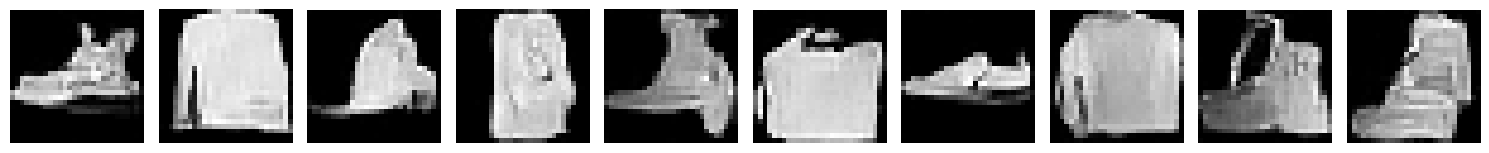

In [6]:
@torch.no_grad()
def sample(model, scheduler, n_samples=10):
    model.eval()
    # Start with pure noise
    x = torch.randn((n_samples, 1, 28, 28)).to(device)
    
    for i in tqdm(reversed(range(T)), total=T, desc="Sampling"):
        t = torch.full((n_samples,), i, device=device, dtype=torch.long)
        
        predicted_noise = model(x, t)
        
        alpha_t = scheduler.alpha[t].view(-1, 1, 1, 1)
        alpha_bar_t = scheduler.alpha_bar[t].view(-1, 1, 1, 1)
        beta_t = scheduler.beta[t].view(-1, 1, 1, 1)
        
        # The specific formulation for the reverse step
        x = (1 / torch.sqrt(alpha_t)) * (x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * predicted_noise)
        
        # Add Langevin noise if not the final step
        if i > 0:
            z = torch.randn_like(x)
            x = x + torch.sqrt(beta_t) * z
            
    # Rescale back to [0, 1] for visualization
    x = (x.clamp(-1, 1) + 1) / 2
    return x

sampled_images = sample(model, scheduler)

# Visualization
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(sampled_images[i].squeeze().cpu().numpy(), cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()